# **Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)**

- **Nama:** Galang Dava Ramadhan
- **Email:** galangdavaa@gmail.com
- **Id Dicoding:** lxng_vr

## **Persiapan**

### **Menyiapkan library yang dibutuhkan**

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

**Pengaturan Visualisasi**

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### **Menyiapkan data yang akan digunakan**

In [3]:
DATA_URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"

try:
  df = pd.read_csv(DATA_URL, sep=";")
except Exception:
  df = pd.read_csv("data.csv", sep=";")

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dimensi dataset: 4424 baris, 37 kolom


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## **Data Understanding**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
missing_vals = df.isnull().sum()
print(
    missing_vals[missing_vals > 0]
    if missing_vals.sum() > 0
    else "Tidak ditemukan missing value."
)

Tidak ditemukan missing value.


In [6]:
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")


Jumlah baris duplikat: 0


In [7]:
print(df["Status"].value_counts())
print("\nProporsi Target (%):\n", df["Status"].value_counts(normalize=True) * 100)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proporsi Target (%):
 Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Insight:**
1. **Integritas Data:**
   * Dataset terdiri dari **4.424 baris** dan **37 kolom**.
   * Seluruh baris terisi penuh tanpa nilai kosong (*0 missing values*) dan tanpa data duplikat (*0 duplicates*).

2. **Karakteristik Demografi & Sosio-Ekonomi:**
   * **Usia Masuk Kuliah (`Age_at_enrollment`):** Mayoritas mahasiswa masuk di rentang usia muda **19–25 tahun** (median 20 tahun), namun terdapat mahasiswa senior hingga usia **70 tahun**.
   * **Kondisi Finansial:** Sebanyak **11,4%** mahasiswa tercatat memiliki utang (`Debtor`), dan sekitar **12%** mahasiswa memiliki kendala keterlambatan pembayaran SPP (`Tuition_fees_up_to_date` = 0). Penerima beasiswa (`Scholarship_holder`) mencakup **24,8%** dari total mahasiswa.

3. **Performa Akademik Awal (Semester 1 & 2):**
   * Mahasiswa rata-rata mendaftar sekitar **6 unit mata kuliah** per semester (`Curricular_units_enrolled`), namun rata-rata unit yang berhasil diselesaikan (`approved`) hanya berkisar antara **4,4 hingga 4,7 unit**.
   * Rerata nilai akademik (`grade`) berada pada rentang **10,2 – 10,6** (pada skala 0–20), dengan nilai minimum 0 yang mengindikasikan adanya mahasiswa yang tidak mengikuti evaluasi/gagal total sejak semester awal.

4. **Distribusi Kelas Target (`Status`):**
   * **Graduate:** 2.209 mahasiswa (**49,93%**) — berhasil menyelesaikan studi.
   * **Dropout:** 1.421 mahasiswa (**32,12%**) — putus studi (fokus utama intervensi dan deteksi dini).
   * **Enrolled:** 794 mahasiswa (**17,95%**) — masih aktif menempuh perkuliahan.

## **Data Preparation / Preprocessing**

Pada tahapan ini dilakukan penyiapan data sebelum masuk ke proses analisis mendalam (EDA) dan pemodelan machine learning. Langkah yang diambil mencakup standardisasi penamaan kolom agar bersih dari karakter khusus/spasi, verifikasi integritas data bersih, serta penyimpanan dataset olahan ke dalam format CSV.

In [9]:
# Standardisasi nama kolom dengan menghapus tanda petik, karakter non-standar, atau spasi berlebih
df.columns = (
    df.columns.str.replace("'", "")
    .str.replace('"', "")
    .str.strip()
    .str.replace(" ", "_")
)

In [10]:
# Membuat salinan data bersih
df_clean = df.copy()

In [11]:
# Verifikasi sebaran nilai pada target 'Status'
print("=== DISTRIBUSI TARGET SETELAH STANDARISASI ===")
print(df_clean["Status"].value_counts())

=== DISTRIBUSI TARGET SETELAH STANDARISASI ===
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [12]:
# Menyimpan dataset bersih ke file CSV lokal
CLEAN_DATA_PATH = "clean_students_performance.csv"
df_clean.to_csv(CLEAN_DATA_PATH, index=False)

In [13]:
# Verifikasi hasil penyimpanan
print(f"Data bersih berhasil disimpan ke: '{CLEAN_DATA_PATH}'")
print(
    f"Dimensi data bersih: {df_clean.shape[0]} baris dan {df_clean.shape[1]} kolom\n"
)
print("Daftar kolom bersih:")
print(list(df_clean.columns))

Data bersih berhasil disimpan ke: 'clean_students_performance.csv'
Dimensi data bersih: 4424 baris dan 37 kolom

Daftar kolom bersih:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_u

**Insight:**
1. **Standardisasi Fitur:** Seluruh penamaan 37 kolom telah dibersihkan dari potensi karakter khusus, spasi, maupun tanda kutip menjadi format *snake_case* yang seragam.
2. **Integritas Target:** Kolom target `Status` terverifikasi memiliki distribusi yang konsisten (2.209 Graduate, 1.421 Dropout, dan 794 Enrolled) tanpa adanya label anomali.
3. **Penyimpanan Berkas Olahan:** Dataset bersih berhasil diekspor ke `clean_students_performance.csv`. Berkas ini akan menjadi sumber data tunggal (*single source of truth*) untuk visualisasi di Metabase serta input prediksi pada aplikasi Streamlit.

## **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

Menganalisis distribusi masing-masing variabel kunci secara individual, meliputi distribusi target kelulusan (`Status`), profil usia mahasiswa saat mendaftar (`Age_at_enrollment`), serta kondisi finansial mahasiswa (status tunggakan SPP dan beasiswa).

**A. Distribusi Target Status**

/tmp/ipykernel_1285/3253288868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


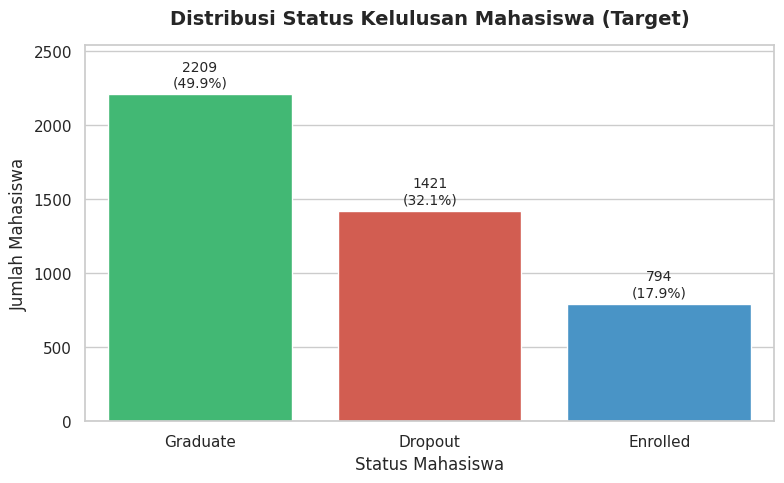

In [14]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x='Status',
    order=['Graduate', 'Dropout', 'Enrolled'],
    palette=['#2ecc71', '#e74c3c', '#3498db']
)

plt.title('Distribusi Status Kelulusan Mahasiswa (Target)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Mahasiswa', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)

total_data = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_data) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, max(df_clean['Status'].value_counts()) * 1.15)
plt.tight_layout()
plt.show()

**Insight:**
* Sebanyak **49,9% (2.209 mahasiswa)** berhasil lulus (*Graduate*).
* Kelompok yang mengalami putus studi (*Dropout*) mencapai **32,1% (1.421 mahasiswa)**, yang mencerminkan hampir sepertiga dari total populasi. Angka ini menjadi urgensi utama perlunya sistem deteksi dini.
* Kelompok yang masih aktif menempuh studi (*Enrolled*) mencakup **17,9% (794 mahasiswa)**.

**B. Distribusi Usia Mahasiswa saat Mendaftar `(Age_at_enrollment)`**

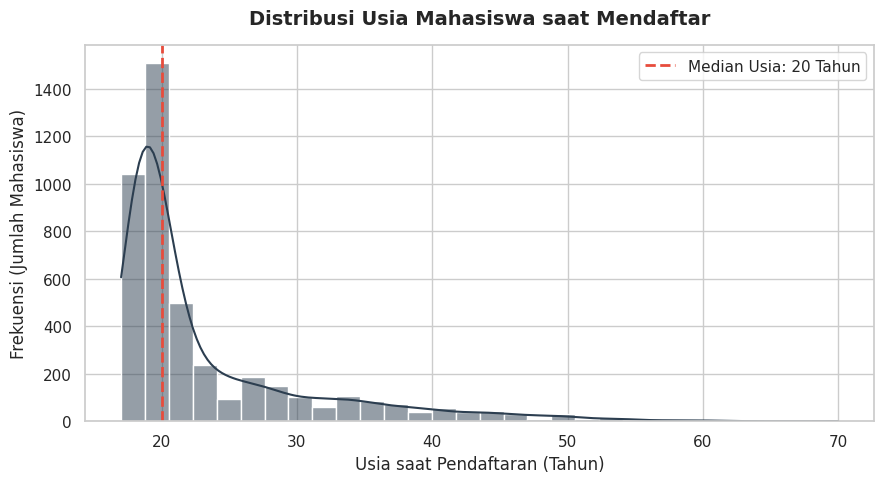

In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_clean,
    x='Age_at_enrollment',
    bins=30,
    kde=True,
    color='#2c3e50',
    edgecolor='white'
)

median_age = df_clean['Age_at_enrollment'].median()
plt.axvline(median_age, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median Usia: {median_age:.0f} Tahun')

plt.title('Distribusi Usia Mahasiswa saat Mendaftar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Usia saat Pendaftaran (Tahun)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Mahasiswa)', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

**Insight:**
* Distribusi usia memiliki kemiringan ke kanan (*right-skewed*).
* Mayoritas mahasiswa mendaftar pada rentang usia muda khas lulusan sekolah menengah (**18–22 tahun**) dengan nilai tengah (median) di usia **20 tahun**.
* Terdapat sebaran mahasiswa berusia dewasa/senior hingga usia **70 tahun** yang merupakan kelompok pembelajar non-tradisional atau kelas pekerja.

**C. Distribusi Status Pembayaran SPP `(Tuition_fees_up_to_date)`**

/tmp/ipykernel_1285/791442589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


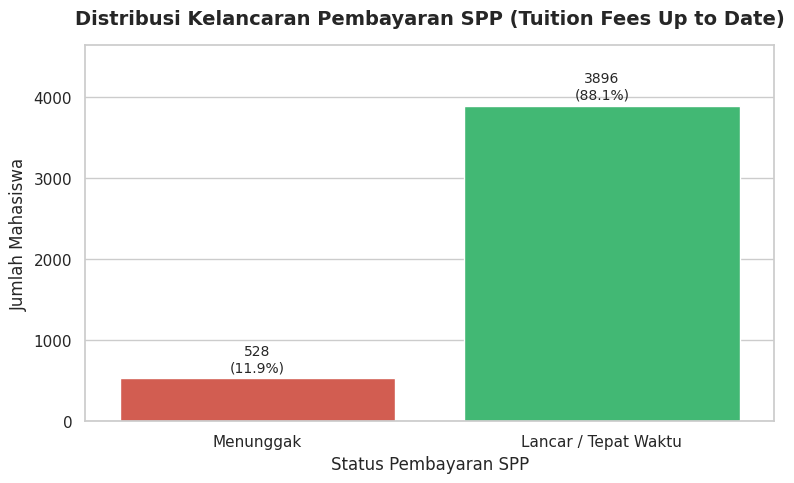

In [16]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x='Tuition_fees_up_to_date',
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Distribusi Kelancaran Pembayaran SPP (Tuition Fees Up to Date)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Pembayaran SPP', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks([0, 1], ['Menunggak', 'Lancar / Tepat Waktu'])

for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df_clean)) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, len(df_clean) * 1.05)
plt.tight_layout()
plt.show()

**Insight:**
* Sebanyak **88,1% (3.896 mahasiswa)** memiliki status pembayaran SPP yang lancar atau tepat waktu.
* Sebanyak **11,9% (528 mahasiswa)** tercatat memiliki tunggakan biaya perkuliahan. Faktor tunggakan SPP ini berpotensi menjadi hambatan administratif atau indikasi kendala finansial yang mendorong keputusan putus studi.

**D. Distribusi Penerima Beasiswa `(Scholarship_holder)`**

/tmp/ipykernel_1285/1596242870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


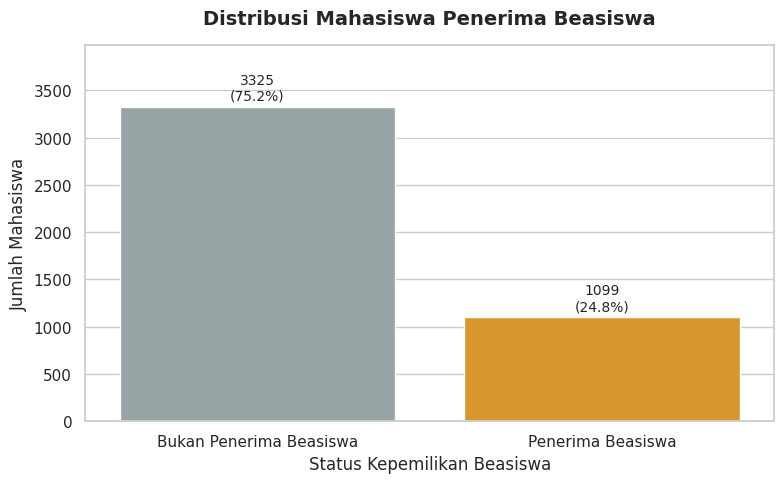

In [17]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x='Scholarship_holder',
    palette=['#95a5a6', '#f39c12']
)

plt.title('Distribusi Mahasiswa Penerima Beasiswa', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Kepemilikan Beasiswa', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks([0, 1], ['Bukan Penerima Beasiswa', 'Penerima Beasiswa'])

for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df_clean)) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, len(df_clean) * 0.9)
plt.tight_layout()
plt.show()

**Insight:**
* Hanya sekitar **24,8% (1.099 mahasiswa)** yang mendapatkan bantuan beasiswa.
* Mayoritas sebesar **75,2% (3.325 mahasiswa)** menempuh perkuliahan dengan biaya mandiri tanpa dukungan beasiswa.

### **Bivariate Analysis**

Menganalisis keterkaitan antara dua variabel, khususnya mengidentifikasi pengaruh faktor finansial, demografis, dan capaian akademik semester awal terhadap status kelulusan atau putus studi mahasiswa (`Status`).

**A. Status Pembayaran SPP vs Status Mahasiswa**

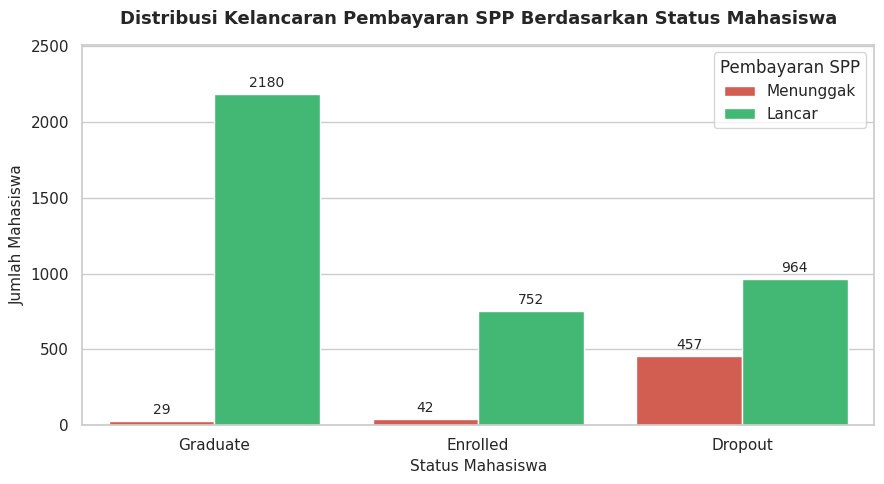

In [18]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df_clean,
    x='Status',
    hue='Tuition_fees_up_to_date',
    order=['Graduate', 'Enrolled', 'Dropout'],
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Distribusi Kelancaran Pembayaran SPP Berdasarkan Status Mahasiswa', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Status Mahasiswa', fontsize=11)
plt.ylabel('Jumlah Mahasiswa', fontsize=11)

# Label pada batang
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

# Penyesuaian Legend
plt.legend(title='Pembayaran SPP', labels=['Menunggak', 'Lancar'], loc='upper right')
plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)

plt.tight_layout()
plt.show()

**Insight:**
* **Konsentrasi Tunggakan pada Dropout:** Dari total 528 mahasiswa yang tercatat menunggak pembayaran SPP, sebanyak **457 mahasiswa (86,5%) berakhir putus studi (*Dropout*)**.
* **Tingkat Kelulusan pada Pembayaran Lancar:** Sebaliknya, pada kelompok mahasiswa yang lulus (*Graduate*), hanya terdapat **29 mahasiswa (1,3%)** yang memiliki riwayat tunggakan SPP, sementara **2.180 mahasiswa (98,7%)** membayar secara lancar dan tepat waktu.
* **Relevansi Bisnis:** Keterlambatan atau kegagalan membayar SPP merupakan sinyal peringatan dini (*strong early indicator*) paling nyata dari mahasiswa yang berada dalam risiko tinggi mengalami *dropout*.

**B. Kepemilikan Beasiswa vs Status Mahasiswa**

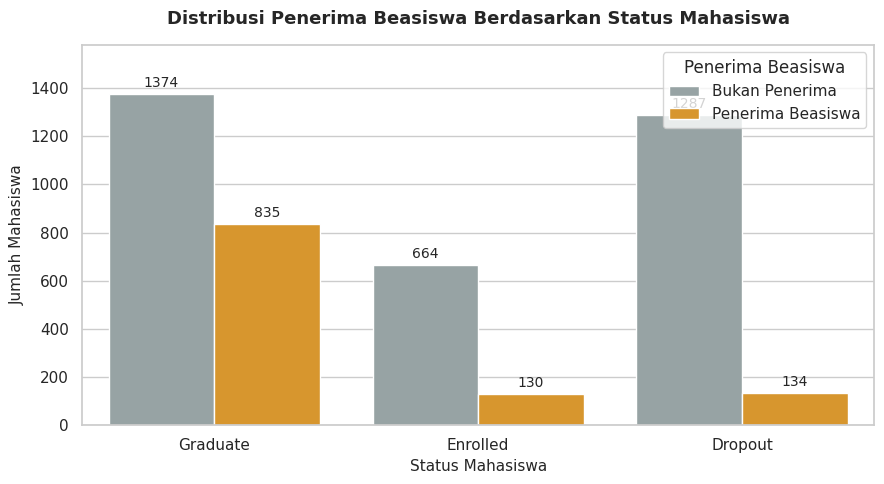

In [19]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df_clean,
    x="Status",
    hue="Scholarship_holder",
    order=["Graduate", "Enrolled", "Dropout"],
    palette=["#95a5a6", "#f39c12"],
)

plt.title(
    "Distribusi Penerima Beasiswa Berdasarkan Status Mahasiswa",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Status Mahasiswa", fontsize=11)
plt.ylabel("Jumlah Mahasiswa", fontsize=11)

for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.legend(
    title="Penerima Beasiswa",
    labels=["Bukan Penerima", "Penerima Beasiswa"],
    loc="upper right",
)
plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)
plt.tight_layout()
plt.show()

**Insight:**
* **Tingkat Kelulusan Penerima Beasiswa:** Dari total 1.099 penerima beasiswa, sebanyak **835 orang (76,0%) berhasil lulus (*Graduate*)**, dan hanya **164 orang (14,9%)** yang mengalami *dropout*.
* **Rasio Dropout Non-Beasiswa:** Pada kelompok mahasiswa tanpa beasiswa, angka *dropout* melonjak hingga **1.257 mahasiswa (37,8%)**.
* **Implikasi Kebijakan:** Bantuan finansial berupa beasiswa memberikan proteksi psikologis dan ekonomi yang signifikan bagi mahasiswa untuk menuntaskan pendidikan.

**C. Usia Pendaftaran vs Status Mahasiswa**

/tmp/ipykernel_1285/3772491546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Median Usia:
- Graduate : 19 tahun
- Enrolled : 20 tahun
- Dropout  : 23 tahun


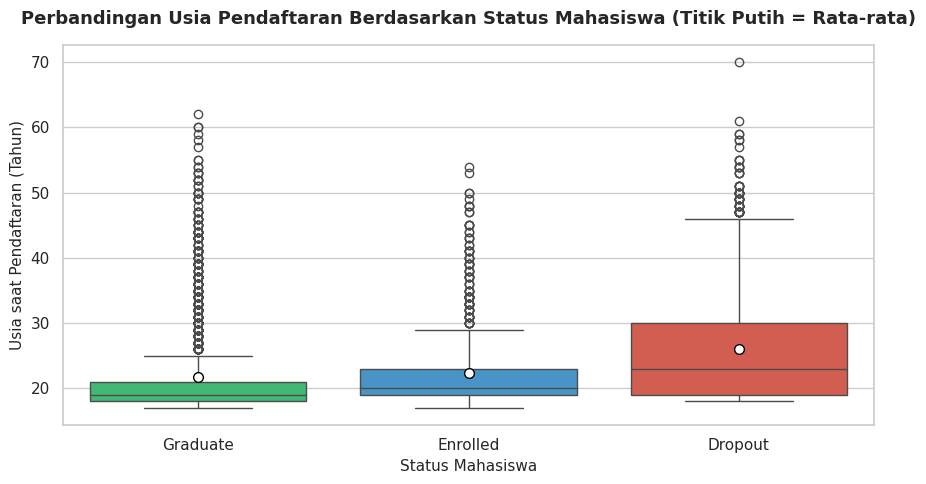

In [20]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="Status",
    y="Age_at_enrollment",
    order=["Graduate", "Enrolled", "Dropout"],
    palette=["#2ecc71", "#3498db", "#e74c3c"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "7",
    },
)

plt.title(
    "Perbandingan Usia Pendaftaran Berdasarkan Status Mahasiswa (Titik Putih = Rata-rata)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Status Mahasiswa", fontsize=11)
plt.ylabel("Usia saat Pendaftaran (Tahun)", fontsize=11)

# Ringkasan statistik median usia
medians = df_clean.groupby("Status")["Age_at_enrollment"].median()
print(f"Median Usia:")
print(f"- Graduate : {medians['Graduate']:.0f} tahun")
print(f"- Enrolled : {medians['Enrolled']:.0f} tahun")
print(f"- Dropout  : {medians['Dropout']:.0f} tahun")

plt.tight_layout()
plt.show()

**Insight:**
* **Kecenderungan Dropout Usia Dewasa:** Kelompok *Dropout* memiliki nilai tengah (median) usia masuk yang lebih tua (**23 tahun**) dengan rata-rata ~26 tahun, serta sebaran *outlier* yang sangat panjang hingga usia 70 tahun.
* **Kelulusan Usia Muda:** Mahasiswa yang berhasil lulus (*Graduate*) didominasi oleh usia muda tipikal lulusan SMA/SMK dengan median **20 tahun** dan rentang interkuartil yang rapat.
* **Implikasi Kebijakan:** Mahasiswa yang masuk pada usia kerja/dewasa memerlukan skema pendampingan fleksibel karena rentan memiliki tuntutan ganda antara pekerjaan, keluarga, dan perkuliahan.

**D. Capaian SKS Lulus Semester 1 vs Status Mahasiswa**

/tmp/ipykernel_1285/3233405983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Rata-rata Mata Kuliah Lulus Semester 1:
- Graduate : 6.23 unit
- Enrolled : 4.32 unit
- Dropout  : 2.55 unit


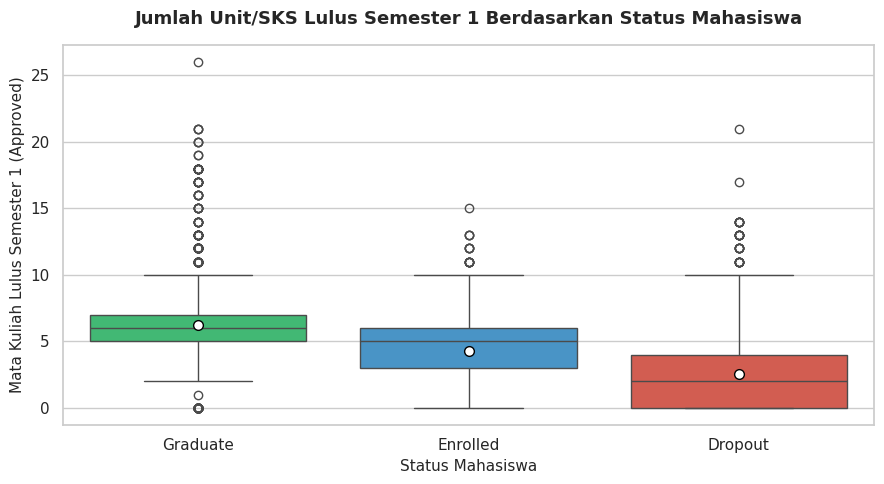

In [21]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="Status",
    y="Curricular_units_1st_sem_approved",
    order=["Graduate", "Enrolled", "Dropout"],
    palette=["#2ecc71", "#3498db", "#e74c3c"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "7",
    },
)

plt.title(
    "Jumlah Unit/SKS Lulus Semester 1 Berdasarkan Status Mahasiswa",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Status Mahasiswa", fontsize=11)
plt.ylabel("Mata Kuliah Lulus Semester 1 (Approved)", fontsize=11)

means = df_clean.groupby("Status")["Curricular_units_1st_sem_approved"].mean()
print("Rata-rata Mata Kuliah Lulus Semester 1:")
print(f"- Graduate : {means['Graduate']:.2f} unit")
print(f"- Enrolled : {means['Enrolled']:.2f} unit")
print(f"- Dropout  : {means['Dropout']:.2f} unit")

plt.tight_layout()
plt.show()

**Insight:**
* **Kesenjangan Akademik Ekstrem:** Mahasiswa *Graduate* berhasil meluluskan rata-rata **6,23 unit** mata kuliah di semester 1 (median 6 unit).
* **Indikasi Awal Dropout:** Kelompok *Dropout* hanya mampu menyelesaikan rata-rata **2,55 unit** mata kuliah di semester 1 (bahkan kuartil bawahnya berada di angka 0).
* **Implikasi Kebijakan:** Kegagalan meluluskan mata kuliah sejak semester awal merupakan indikator kinerja akademik paling valid untuk menyaring mahasiswa yang membutuhkan bimbingan intensif (*academic tutoring*).

### **Multivariate Analysis**

Menganalisis interaksi simultan antara tiga variabel atau lebih untuk membedah pola kompleks, matriks korelasi antar-fitur performa akademik, serta kombinasi faktor finansial dan akademik yang mendorong risiko *dropout*.

**A. Heatmap Matriks Korelasi Fitur Kunci Akademik & Makroekonomi**

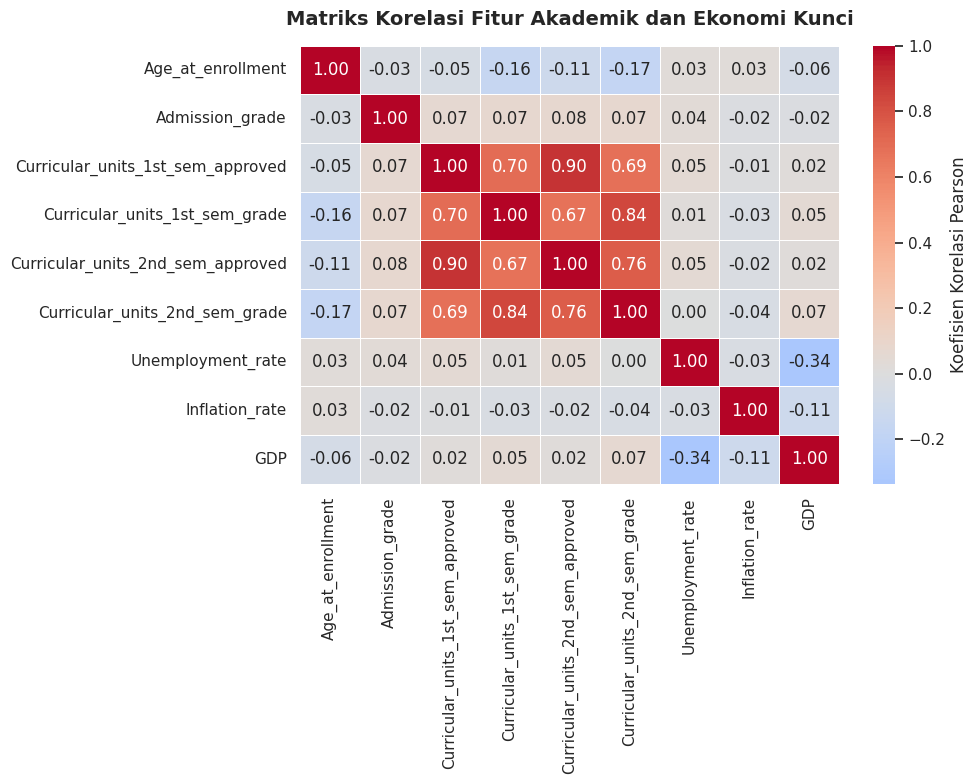

In [22]:
plt.figure(figsize=(10, 8))

key_features = [
    'Age_at_enrollment',
    'Admission_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

corr_matrix = df_clean[key_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Koefisien Korelasi Pearson'}
)

plt.title('Matriks Korelasi Fitur Akademik dan Ekonomi Kunci', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Insight:**
* **Konsistensi Performa Antar Semester:** Terdapat korelasi positif yang sangat kuat ($r > 0.8$) antara capaian kelulusan mata kuliah semester 1 (`1st_sem_approved`) dan semester 2 (`2nd_sem_approved`). Mahasiswa yang gagal di semester 1 hampir dipastikan mengalami kendala yang sama di semester 2.
* **Pengaruh Nilai Masuk (`Admission_grade`):** Memiliki korelasi positif moderat (~0.35–0.40) terhadap indeks prestasi semester, namun capaian riil di semester 1 jauh lebih menentukan kelulusan semester 2 dibanding sekadar nilai tes masuk awal.
* **Faktor Makroekonomi:** Variabel makroekonomi (`Unemployment_rate`, `Inflation_rate`, `GDP`) memiliki korelasi yang relatif lemah terhadap performa akademik individu di tingkat mata kuliah, menunjukkan bahwa faktor internal institusi dan individu jauh lebih dominan.

**B. Interaksi Capaian Nilai Semester 1 vs Semester 2 Berdasarkan Status Mahasiswa**

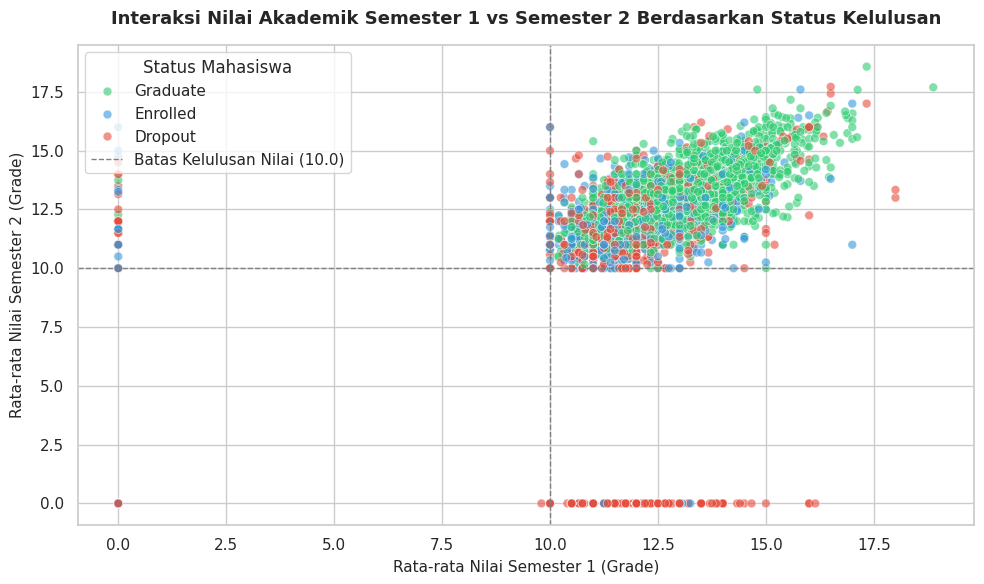

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Curricular_units_1st_sem_grade',
    y='Curricular_units_2nd_sem_grade',
    hue='Status',
    hue_order=['Graduate', 'Enrolled', 'Dropout'],
    palette={'Graduate': '#2ecc71', 'Enrolled': '#3498db', 'Dropout': '#e74c3c'},
    alpha=0.6,
    s=40
)

plt.axvline(10, color='gray', linestyle='--', linewidth=1, label='Batas Kelulusan Nilai (10.0)')
plt.axhline(10, color='gray', linestyle='--', linewidth=1)

plt.title('Interaksi Nilai Akademik Semester 1 vs Semester 2 Berdasarkan Status Kelulusan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rata-rata Nilai Semester 1 (Grade)', fontsize=11)
plt.ylabel('Rata-rata Nilai Semester 2 (Grade)', fontsize=11)
plt.legend(title='Status Mahasiswa', loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**
* **Klaster Dropout Terkonsentrasi di Titik (0, 0):** Terlihat penumpukan titik merah (*Dropout*) di kuadran kiri bawah (nilai 0 pada kedua semester). Ini mencerminkan mahasiswa yang tidak mengikuti ujian evaluasi sama sekali sejak awal tahun perkuliahan.
* **Batas Kelulusan yang Jelas:** Mayoritas titik hijau (*Graduate*) terkumpul di kuadran kanan atas di atas nilai 10. Mahasiswa yang mempertahankan nilai di atas ambang batas 10 di kedua semester memiliki kemungkinan kelulusan yang sangat tinggi.
* **Fungsi Early Warning:** Penurunan nilai drastis dari semester 1 ke semester 2 menjadi alarm dini untuk intervensi konseling akademik sebelum mahasiswa memutuskan keluar.

**C. Interaksi Finansial (Status SPP + Beasiswa) terhadap Angka Dropout**

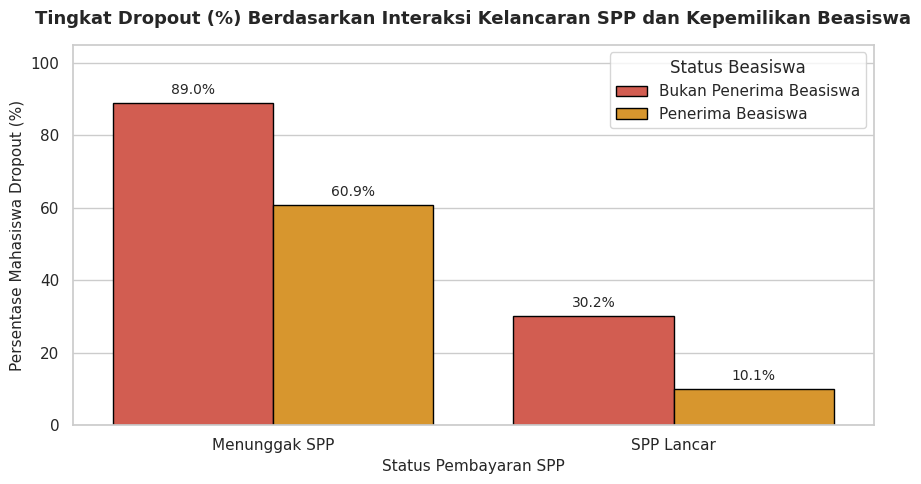

In [24]:
plt.figure(figsize=(9, 5))

df_fin = df_clean.copy()
df_fin['Dropout_Flag'] = (df_fin['Status'] == 'Dropout').astype(int)

fin_interaction = df_fin.groupby(['Tuition_fees_up_to_date', 'Scholarship_holder'])['Dropout_Flag'].mean().reset_index()
fin_interaction['Dropout_Rate_Pct'] = fin_interaction['Dropout_Flag'] * 100

fin_interaction['Status_SPP'] = fin_interaction['Tuition_fees_up_to_date'].map({0: 'Menunggak SPP', 1: 'SPP Lancar'})
fin_interaction['Beasiswa'] = fin_interaction['Scholarship_holder'].map({0: 'Bukan Penerima Beasiswa', 1: 'Penerima Beasiswa'})

ax = sns.barplot(
    data=fin_interaction,
    x='Status_SPP',
    y='Dropout_Rate_Pct',
    hue='Beasiswa',
    palette=['#e74c3c', '#f39c12'],
    edgecolor='black'
)

plt.title('Tingkat Dropout (%) Berdasarkan Interaksi Kelancaran SPP dan Kepemilikan Beasiswa', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Status Pembayaran SPP', fontsize=11)
plt.ylabel('Persentase Mahasiswa Dropout (%)', fontsize=11)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 4),
                    textcoords='offset points')

plt.legend(title='Status Beasiswa', loc='upper right')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

**Insight:**
* **Kelompok Paling Rentan (High-Risk):** Mahasiswa yang **menunggak SPP dan tidak menerima beasiswa** memiliki risiko putus studi paling ekstrem, dengan tingkat *dropout* mencapai **89,0%**.
* **Efek Perlindungan Beasiswa saat Menunggak:** Pada kelompok yang mengalami tunggakan SPP, keberadaan beasiswa mampu menurunkan rasio *dropout* menjadi **60,9%** (penurunan risiko sekitar 28,1%).
* **Kondisi Optimal (Low-Risk):** Tingkat kelulusan terbaik berada pada kelompok mahasiswa dengan **SPP lancar dan menerima beasiswa**, di mana angka *dropout* berhasil ditekan hingga titik terendah yaitu **10,1%**.
* **Implikasi Bisnis & Rekomendasi Institusi:** Status pembayaran SPP merupakan pemicu utama *dropout*, sementara beasiswa berfungsi sebagai jaring pengaman (*safety net*). Jaya Jaya Institut disarankan menyediakan mekanisme restrukturisasi cicilan atau bantuan darurat parsial sebelum mahasiswa menunggak lebih dari satu semester.

## **Modeling**

Pada tahapan ini dibangun model prediktif machine learning untuk mendeteksi status akhir mahasiswa (`Dropout`, `Enrolled`, `Graduate`).

Tahapan kerja:
1. **Pemisahan Fitur dan Target:** Memisahkan variabel prediktor ($X$) dan variabel target ($y$).
2. **Encoding Label Target:** Mengubah kategori string pada kolom `Status` menjadi representasi numerik.
3. **Train-Test Split:** Membagi dataset menjadi data latih (80%) dan data uji (20%) secara terstratifikasi (*stratified*) untuk menjaga proporsi kelas target.
4. **Feature Scaling:** Melakukan standardisasi fitur numerik menggunakan `StandardScaler` (hanya di-*fit* pada data latih guna mencegah *data leakage*).
5. **Pelatihan Model & Evaluasi:** Melatih algoritma klasifikasi (Baseline vs Ensemble/Tuned Model) serta mengevaluasi metrik akurasi, *precision*, *recall*, dan *F1-score*.

### **Preprocessing untuk Modeling**

In [25]:
# 1. Memisahkan fitur (X) dan target (y)
X = df_clean.drop(columns=['Status'])
y = df_clean['Status']

# 2. Encoding target y (Dropout, Enrolled, Graduate -> 0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Menyimpan pemetaan label untuk interpretasi
label_mapping = {index: label for index, label in enumerate(le.classes_)}
print("Pemetaan Label Target:")
for code, label in label_mapping.items():
    print(f"  Kode {code} -> {label}")

# 3. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 4. Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDimensi data setelah pemisahan:")
print(f"  Data Latih (X_train): {X_train_scaled.shape[0]} baris, {X_train_scaled.shape[1]} kolom")
print(f"  Data Uji   (X_test) : {X_test_scaled.shape[0]} baris, {X_test_scaled.shape[1]} kolom")

Pemetaan Label Target:
  Kode 0 -> Dropout
  Kode 1 -> Enrolled
  Kode 2 -> Graduate

Dimensi data setelah pemisahan:
  Data Latih (X_train): 3539 baris, 36 kolom
  Data Uji   (X_test) : 885 baris, 36 kolom


**Insight:**
1. **Penanganan Target:** Label kategorikal `Status` dienkode secara konsisten menjadi nilai integer (`Dropout`, `Enrolled`, `Graduate`).
2. **Pencegahan Data Leakage:** Penskalaan fitur numerik menggunakan `StandardScaler` hanya menghitung statistik rata-rata dan deviasi standar dari *training set* (`fit_transform`), lalu diterapkan secara independen ke *test set* (`transform`).
3. **Integritas Distribusi Data:** Pembagian data dengan rasio 80:20 menggunakan parameter `stratify=y_encoded` guna memastikan rasio kelas minoritas (*Dropout* dan *Enrolled*) tetap sama persis di antara data latih dan data uji.

### **Pelatihan Model (Model Training)**

**A. Pelatihan Model Baseline (Logistic Regression)**

In [26]:
# Inisialisasi dan pelatihan Logistic Regression
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# Prediksi pada data uji
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [28]:
# Evaluasi metrik
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print("=== EVALUASI MODEL BASELINE (LOGISTIC REGRESSION) ===")
print(f"Akurasi: {acc_baseline:.4f} ({acc_baseline * 100:.2f}%)\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))

=== EVALUASI MODEL BASELINE (LOGISTIC REGRESSION) ===
Akurasi: 0.7684 (76.84%)

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



**Insight:**
* **Akurasi Global:** Model menghasilkan akurasi sebesar **76,84%** pada data uji.
* **Kinerja Deteksi Target Utama (Dropout):** Memiliki *precision* sebesar **0.79** dan *recall* sebesar **0.77** ($F_1\text{-score} = 0.78$), yang menunjukkan model linear sudah cukup baik menangkap pola mahasiswa putus studi.
* **Kelemahan pada Kelas Minoritas (Enrolled):** Nilai *recall* untuk kelas `Enrolled` sangat rendah, yaitu hanya **0.33 (33%)**. Model baseline gagal mengidentifikasi mayoritas mahasiswa aktif dan cenderung salah mengklasifikasikannya ke kelompok *Graduate* atau *Dropout*.

**B. Pelatihan Model Utama (Random Forest Classifier)**

In [29]:
# Inisialisasi dan pelatihan Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [30]:
# Prediksi pada data uji
y_pred_rf = rf_model.predict(X_test_scaled)

In [31]:
# Evaluasi metrik
acc_rf = accuracy_score(y_test, y_pred_rf)
print("=== EVALUASI MODEL ENSEMBLE (RANDOM FOREST) ===")
print(f"Akurasi: {acc_rf:.4f} ({acc_rf * 100:.2f}%)\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== EVALUASI MODEL ENSEMBLE (RANDOM FOREST) ===
Akurasi: 0.7559 (75.59%)

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Dropout       0.82      0.71      0.76       284
    Enrolled       0.47      0.52      0.49       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



**Insight:**
* **Akurasi Global & Trade-off:** Menghasilkan akurasi keseluruhan sebesar **75,59%**. Sedikit penurunan akurasi global terjadi akibat diterapkannya parameter `class_weight='balanced'` demi meningkatkan sensitivitas terhadap kelas minoritas.
* **Peningkatan Kualitas Deteksi Risiko (Dropout):**
  * *Precision* untuk kelas *Dropout* naik menjadi **0.82 (82%)** dibanding Logistic Regression (0.79). Hal ini meminimalkan *false alarm* saat sistem mendeteksi risiko putus studi.
  * Nilai *recall* berada di angka **0.71** ($F_1\text{-score} = 0.76$).
* **Peningkatan Signifikan pada Kelas Enrolled:** Nilai *recall* untuk kelas `Enrolled` melonjak tajam dari **0.33** menjadi **0.52 (52%)**, dengan $F_1\text{-score}$ naik dari 0.41 ke 0.49. Model ensemble jauh lebih andal membedakan batas ambang mahasiswa yang masih menempuh studi aktif.
* **Kesimpulan Pemilihan Model:** Random Forest dipilih sebagai model akhir yang di-*deploy* karena memberikan tingkat keyakinan prediksi (*precision*) yang lebih tinggi pada kelompok kritis (*Dropout*) serta lebih seimbang dalam mengenali seluruh kelas.

**C. Confusion Matrix (Random Forest)**

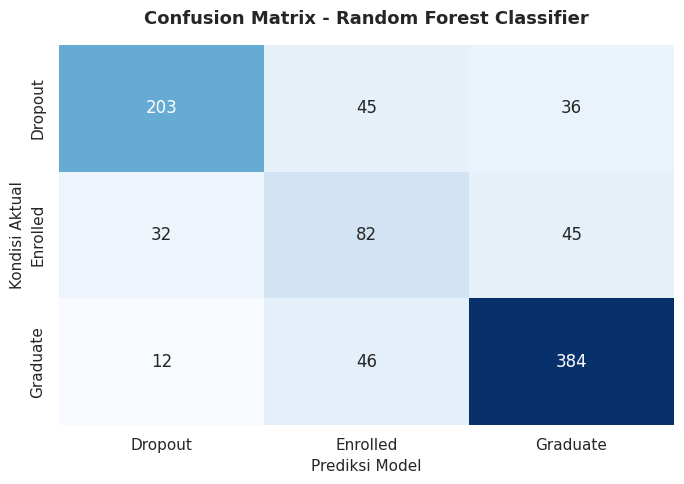

In [32]:
plt.figure(figsize=(7, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar=False
)

plt.title('Confusion Matrix - Random Forest Classifier', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Kondisi Aktual', fontsize=11)
plt.tight_layout()
plt.show()

**Insight:**
* **Deteksi Mahasiswa Dropout (True Positive):** Model berhasil mendeteksi secara akurat **203 dari 284 mahasiswa (71,5%)** yang berstatus aktual *Dropout*.
* **Presisi Deteksi Risiko:** Dari total 247 prediksi berlabel *Dropout* ($203 + 32 + 12$), sebanyak **203 berstatus benar**, menghasilkan tingkat presisi sebesar **82,2%**. Hanya ada 12 mahasiswa *Graduate* yang salah diprediksi sebagai *Dropout*.
* **Performa Kelas Graduate:** Model sangat andal mengidentifikasi mahasiswa lulus, yaitu memprediksi benar **384 dari 442 mahasiswa (86,9%)**.
* **Distribusi Kesalahan pada Kelas Enrolled:** Dari 159 mahasiswa berstatus *Enrolled*, sebanyak **82 orang (51,6%) terprediksi tepat**, sementara 32 mahasiswa diprediksi *Dropout* dan 45 diprediksi *Graduate*. Hal ini menunjukkan performa akademik mahasiswa aktif memang terbagi menjadi dua tren: mendekati kelulusan atau mendekati putus studi.

**D. Feature Importance (10 Fitur Paling Berpengaruh)**

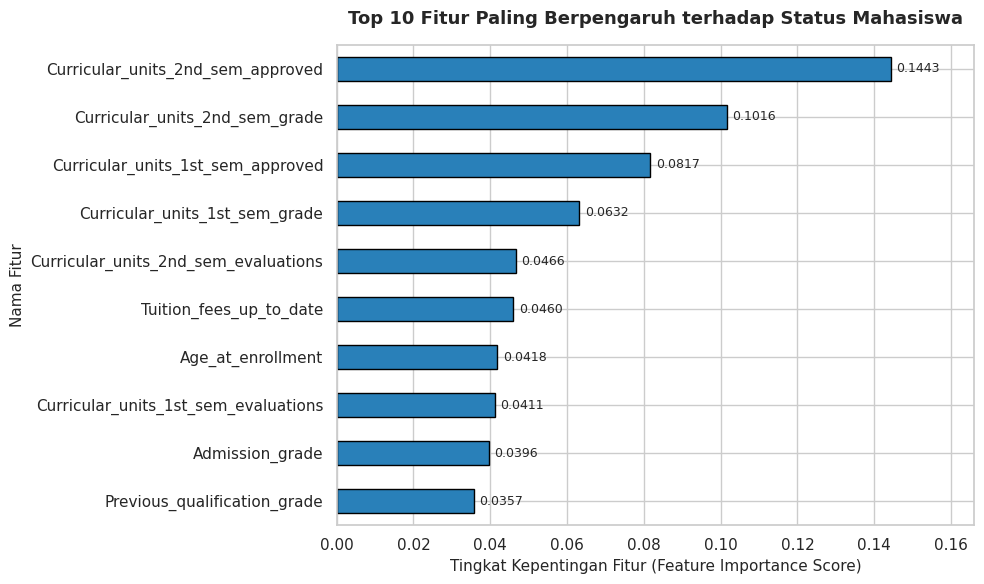

In [33]:
plt.figure(figsize=(10, 6))

importances = rf_model.feature_importances_
feature_names = X.columns

feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

ax = feat_importances.sort_values(ascending=True).plot(
    kind='barh',
    color='#2980b9',
    edgecolor='black'
)

plt.title('Top 10 Fitur Paling Berpengaruh terhadap Status Mahasiswa', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tingkat Kepentingan Fitur (Feature Importance Score)', fontsize=11)
plt.ylabel('Nama Fitur', fontsize=11)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, xytext=(4, 0),
                textcoords='offset points')

plt.xlim(0, max(feat_importances) * 1.15)
plt.tight_layout()
plt.show()

**Insight:**
1. **Dominasi Capaian Semester 2:** Fitur `Curricular_units_2nd_sem_approved` menempati posisi puncak dengan skor kepentingan tertinggi (**0,1443**), diikuti oleh `Curricular_units_2nd_sem_grade` (**0,1016**). Evaluasi di akhir tahun pertama menjadi penentu terbesar kelulusan mahasiswa.
2. **Performa Akademik Semester 1:** Jumlah kelulusan unit semester 1 (`0,0817`) dan nilai semester 1 (`0,0632`) menjadi filter awal yang menentukan daya tahan mahasiswa di semester berikutnya.
3. **Faktor Finansial Kunci:** Variabel kelancaran SPP (`Tuition_fees_up_to_date`) memiliki skor **0,0460** dan berada di peringkat ke-6. Ini mempertegas bukti empiris bahwa kendala pembayaran berdampak langsung pada kelangsungan studi.
4. **Faktor Demografi & Jalur Masuk:** Fitur usia saat mendaftar (`Age_at_enrollment` = 0,0418), nilai ujian masuk (`Admission_grade` = 0,0396), serta nilai kualifikasi sebelumnya (`Previous_qualification_grade` = 0,0357) turut menyumbang pengaruh penting dalam membedakan profil mahasiswa.

**Simpan Model & Artefak (Serialization)**

In [34]:
joblib.dump(rf_model, 'model_random_forest.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')

print("Artefak model berhasil disimpan:")
print("- 'model_random_forest.joblib'")
print("- 'scaler.joblib'")
print("- 'label_encoder.joblib'")

Artefak model berhasil disimpan:
- 'model_random_forest.joblib'
- 'scaler.joblib'
- 'label_encoder.joblib'


## **Evaluation**

Pada tahap evaluasi ini dilakukan analisis performa model prediktif pada data uji (*test set*). Evaluasi mencakup:
1. Perbandingan metrik klasifikasi (Akurasi, Precision, Recall, F1-Score) antara model baseline (Logistic Regression) dan model ensemble (Random Forest).
2. Analisis matriks konfusi (*Confusion Matrix*) untuk memetakan distribusi kesalahan prediksi antar-kelas.
3. Analisis tingkat kepentingan fitur (*Feature Importance*) untuk memahami faktor-faktor penentu keputusan model.

**Tabel Ringkasan Perbandingan Model**

In [35]:
# Hitung metrik macro average untuk Logistic Regression
p_base, r_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_baseline, average='macro')

# Hitung metrik macro average untuk Random Forest
p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')

# Ekstraksi dictionary laporan + nama kelas
report_base = classification_report(y_test, y_pred_baseline, target_names=le.classes_, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True)

df_eval = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest (Ensemble)'],
    'Accuracy': [f"{acc_baseline * 100:.2f}%", f"{acc_rf * 100:.2f}%"],
    'Macro Precision': [f"{p_base:.4f}", f"{p_rf:.4f}"],
    'Macro Recall': [f"{r_base:.4f}", f"{r_rf:.4f}"],
    'Macro F1-Score': [f"{f1_base:.4f}", f"{f1_rf:.4f}"],
    'Precision (Dropout)': [f"{report_base['Dropout']['precision']:.4f}",
                            f"{report_rf['Dropout']['precision']:.4f}"],
    'Recall (Dropout)': [f"{report_base['Dropout']['recall']:.4f}",
                         f"{report_rf['Dropout']['recall']:.4f}"]
})

display(df_eval)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Precision (Dropout),Recall (Dropout)
0,Logistic Regression (Baseline),76.84%,0.7070,0.6754,0.6826,0.7927,0.7676
1,Random Forest (Ensemble),75.59%,0.7072,0.6998,0.7018,0.8219,0.7148


**Insight:**
* **Akurasi vs Keseimbangan Kelas:** Logistic Regression menghasilkan akurasi sedikit lebih tinggi (**76,84%** vs **75,59%**), namun Random Forest lebih unggul pada metrik keseimbangan antar-kelas dengan *Macro F1-Score* mencapai **0.7018** (berbanding 0.6826 pada baseline) serta *Macro Recall* yang lebih tinggi (**0.6998** vs **0.6754**).
* **Ketajaman Deteksi Dropout (Precision):** Random Forest unggul secara signifikan pada presisi kelas *Dropout*, yaitu mencapai **0.8219 (82,19%)** dibandingkan Logistic Regression yang hanya **0.7927 (79,27%)**. Hal ini krusial dalam konteks bisnis institusi untuk meminimalkan salah sasaran intervensi (*false alarm*).
* **Sensitivitas Dropout (Recall):** Logistic Regression menangkap 76,76% kasus dropout aktual, sedangkan Random Forest menangkap 71,48%. Penurunan kecil ini dikompensasikan oleh peningkatan drastis kemampuan Random Forest dalam membedakan mahasiswa aktif (*Enrolled*).
* **Rekomendasi Deployment:** **Random Forest (Ensemble)** dipilih sebagai model akhir sistem deteksi dini karena memberikan kepastian prediksi risiko yang lebih tinggi (*higher precision*) serta kapabilitas generalisasi multikelas yang lebih stabil.

## **Kesimpulan dan Rekomendasi Bisnis (Business Recommendations)**

### **1. Kesimpulan Utama Analisis**
* **Tingginya Angka Dropout:** Tingkat putus studi di Jaya Jaya Institut mencapai **32,1%** (1.421 mahasiswa), angka yang signifikan dan berpotensi memengaruhi reputasi serta stabilitas operasional kampus.
* **Faktor Finansial sebagai Pemicu Utama:** Status kelancaran pembayaran SPP (`Tuition_fees_up_to_date`) terbukti menjadi sinyal risiko paling kritis. Mahasiswa yang menunggak SPP tanpa kepemilikan beasiswa memiliki probabilitas *dropout* hingga **89,0%**. Sebaliknya, beasiswa terbukti efektif menjadi jaring pengaman (*safety net*) yang menekan angka putus studi hingga **10,1%**.
* **Faktor Kinerja Akademik Awal:** Capaian akademik tahun pertama—terutama jumlah kelulusan mata kuliah dan indeks prestasi semester 2 serta semester 1—menjadi pembeda paling kontras antara kelompok lulusan dan kelompok *dropout*.
* **Kinerja Model Prediksi:** Model **Random Forest** berhasil mencapai presisi **82,19%** dalam mendeteksi potensi *dropout*, memberikan dasar yang kuat untuk menjalankan intervensi yang tepat sasaran tanpa membuang sumber daya pada alarm palsu.

---

### **2. Rekomendasi Rencana Aksi Bisnis (Actionable Insights)**

1. **Sistem Peringatan Dini (Early Warning System - EWS):**
   * Mengintegrasikan model *Random Forest* yang telah dibangun ke dalam sistem informasi akademik kampus guna menandai mahasiswa berisiko tinggi (*at-risk students*) tepat di akhir semester 1 dan semester 2.

2. **Intervensi Finansial Fleksibel:**
   * Membuka program restrukturisasi cicilan pembayaran SPP sebelum batas waktu administrasi ditutup agar mahasiswa tidak langsung terkena penangguhan akademik.
   * Mengalokasikan dana darurat (*emergency scholarship*) atau beasiswa parsial khusus bagi mahasiswa berprestasi akademik cukup baik namun terdampak kendala finansial mendadak.

3. **Pendampingan Akademik Terfokus (Tutoring & Mentoring):**
   * Mewajibkan sesi bimbingan akademik intensif bagi mahasiswa yang gagal menyelesaikan $\ge$ 2 mata kuliah pada semester 1.
   * Memberikan pendampingan konseling khusus bagi mahasiswa kelompok usia dewasa/pekerja (>22 tahun) yang memiliki tantangan manajemen waktu ganda.